# Expanding-Window Backtesting — Univariate LSTM

`04_basic_lstm` reports one number from one train/val/test split (train 1989-2014, val 2015-2019,
test 2020-2023). That is one draw — it does not tell us whether the LSTM's edge over persistence
holds up if the split boundary moves, or whether we got lucky (or unlucky) with 2020-2023 in
particular as a test era.

This notebook retrains the same architecture across five expanding-window folds (test years
2019-2023, each with its own 2-year validation window immediately before it and all remaining
history as training data) and checks whether the LSTM-vs-persistence result is stable across
folds, per `src.evaluation_utils.TimeSeriesExpandingWindow`'s expanding-window design (adapted
here for the three-way LSTM split rather than a plain fit/predict model).

In [1]:
import sys; sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_bootstrap import ensure_extent_data
from src.data_utils import load_extent_daily
from src import lstm_utils as L
from src.evaluation_utils import ClimatologyModel, compute_all_metrics, log_model_results

ensure_extent_data()
device = L.get_device()

✓ 'ice_extent_pan_arctic_daily' already populated.
Using device: cpu


## Fold definition

Test years 2019-2023, each an expanding window: validation is the 2 calendar years immediately
before the test year (held out from training, as required by `L.temporal_split`), and training is
everything from 1989 up to the start of that validation window.

In [2]:
TEST_YEARS = [2019, 2020, 2021, 2022, 2023]
VAL_SPAN = 2  # years

folds = []
for test_year in TEST_YEARS:
    val_start = test_year - VAL_SPAN
    folds.append({
        "test_year": test_year,
        "train_years": range(1989, val_start),
        "val_years": range(val_start, test_year),
        "test_years": range(test_year, test_year + 1),
    })

for f in folds:
    print(f"test={f['test_year']} | train={f['train_years'].start}-{f['train_years'].stop - 1} "
          f"| val={f['val_years'].start}-{f['val_years'].stop - 1}")

test=2019 | train=1989-2016 | val=2017-2018
test=2020 | train=1989-2017 | val=2018-2019
test=2021 | train=1989-2018 | val=2019-2020
test=2022 | train=1989-2019 | val=2020-2021
test=2023 | train=1989-2020 | val=2021-2022


In [ ]:
FEATURES = ["extent_mkm2"]
FULL_DF = load_extent_daily(years=range(1989, 2024))

config = L.TrainConfig(
    sequence_length=30,
    forecast_horizon=1,
    hidden_size=64,          # GPU: try 128 first, 256 only as an ablation. This retrains 5 folds
                             # per run, so cost multiplies by 5x whatever you pick -- scale gently.
    num_layers=2,            # GPU: 3 is marginal; change after hidden_size, not instead of it
    dropout=0.2,
    batch_size=64,           # GPU: 128-256 is close to free; avoid pushing much past that
    num_epochs=150,
    learning_rate=1e-3,
    patience=15,
    amp=False,              # set True on CUDA for a free speedup
)
config

In [4]:
fold_results = []
fold_predictions = {}

for f in folds:
    test_year = f["test_year"]
    L.set_seed(config.seed)  # same seed every fold isolates split effects from init effects

    train_df, val_df, test_df = L.temporal_split(
        FULL_DF, f["train_years"], f["val_years"], f["test_years"]
    )

    train_ds = L.SequenceDataset(train_df, config.sequence_length, config.forecast_horizon, features=FEATURES)
    val_ds   = L.SequenceDataset(val_df,   config.sequence_length, config.forecast_horizon, features=FEATURES, scaler=train_ds.scaler)
    test_ds  = L.SequenceDataset(test_df,  config.sequence_length, config.forecast_horizon, features=FEATURES, scaler=train_ds.scaler)

    train_loader = L.make_loader(train_ds, config, shuffle=True)
    val_loader   = L.make_loader(val_ds,   config, shuffle=False)
    test_loader  = L.make_loader(test_ds,  config, shuffle=False)

    model = L.IceExtentLSTM(
        input_size=len(train_ds.features), hidden_size=config.hidden_size,
        num_layers=config.num_layers, forecast_horizon=config.forecast_horizon,
        dropout=config.dropout,
    )
    ckpt_path = f"../models/08_backtest_fold_{test_year}.pt"
    extra = {
        "scaler": train_ds.scaler, "features": train_ds.features, "target": "extent_mkm2",
        "input_size": len(train_ds.features),
        "split": {"train": [f["train_years"].start, f["train_years"].stop - 1],
                  "val": [f["val_years"].start, f["val_years"].stop - 1],
                  "test": [test_year, test_year]},
    }
    print(f"\n=== fold test_year={test_year} ===")
    history = L.train_model(model, train_loader, val_loader, config, device,
                            checkpoint_path=ckpt_path, bundle_extra=extra, verbose=False)
    print(f"epochs_trained={history['epochs_trained']} best_val_loss={history['best_val_loss']:.6f}")

    bundle = L.load_checkpoint(ckpt_path, device=device)
    preds_n, actuals_n = L.predict(bundle["model"], test_loader, device)
    tmean, tstd = train_ds.target_scaler
    preds = L.denormalize(preds_n.flatten(), tmean, tstd)
    actuals = L.denormalize(actuals_n.flatten(), tmean, tstd)

    start = config.sequence_length + config.forecast_horizon - 1
    test_dates = test_ds.dates.iloc[start:start + len(preds)].reset_index(drop=True)
    pers_idx = np.arange(start - 1, start - 1 + len(preds))
    persistence = L.denormalize(test_ds.data[pers_idx, test_ds.target_idx], tmean, tstd)

    clim = ClimatologyModel()
    clim.fit(dates=train_df["date"], values=train_df["extent_mkm2"])
    climatology = clim.predict(test_dates)

    m_lstm = compute_all_metrics(actuals, preds, y_baseline_persistence=persistence, y_baseline_climatology=climatology)
    m_pers = compute_all_metrics(actuals, persistence)

    fold_results.append({
        "test_year": test_year,
        "rmse_lstm": m_lstm["rmse"], "rmse_persistence": m_pers["rmse"],
        "skill_vs_persistence": m_lstm["skill_score_persistence"],
        "skill_vs_climatology": m_lstm["skill_score_climatology"],
        "epochs_trained": history["epochs_trained"],
        "n_test_days": len(actuals),
    })
    fold_predictions[test_year] = {"dates": test_dates, "actuals": actuals, "preds": preds, "persistence": persistence}

results_df = pd.DataFrame(fold_results)
results_df


=== fold test_year=2019 ===


epochs_trained=150 best_val_loss=0.000311

=== fold test_year=2020 ===


epochs_trained=131 best_val_loss=0.000451

=== fold test_year=2021 ===


epochs_trained=98 best_val_loss=0.000338

=== fold test_year=2022 ===


epochs_trained=148 best_val_loss=0.000346

=== fold test_year=2023 ===


epochs_trained=103 best_val_loss=0.000309


,test_year,rmse_lstm,rmse_persistence,skill_vs_persistence,skill_vs_climatology,epochs_trained,n_test_days
0,2019,0.059094,0.088248,0.330360,0.950481,150,335
1,2020,0.080232,0.093512,0.142009,0.938912,131,336
2,2021,0.060154,0.087849,0.315261,0.915858,98,335
3,2022,0.055868,0.083431,0.330375,0.904203,148,335
4,2023,0.056075,0.087811,0.361414,0.925816,103,335


In [5]:
print(f"RMSE (LSTM):        {results_df['rmse_lstm'].mean():.4f} +/- {results_df['rmse_lstm'].std():.4f} Mkm2")
print(f"RMSE (persistence):  {results_df['rmse_persistence'].mean():.4f} +/- {results_df['rmse_persistence'].std():.4f} Mkm2")
print(f"Skill vs persistence: {results_df['skill_vs_persistence'].mean():+.3f} +/- {results_df['skill_vs_persistence'].std():.3f}")
print()
beats_persistence = (results_df["rmse_lstm"] < results_df["rmse_persistence"])
print(f"LSTM beats persistence in {beats_persistence.sum()}/{len(results_df)} folds: "
      f"{dict(zip(results_df['test_year'], beats_persistence))}")

RMSE (LSTM):        0.0623 +/- 0.0102 Mkm2
RMSE (persistence):  0.0882 +/- 0.0036 Mkm2
Skill vs persistence: +0.296 +/- 0.088

LSTM beats persistence in 5/5 folds: {2019: True, 2020: True, 2021: True, 2022: True, 2023: True}


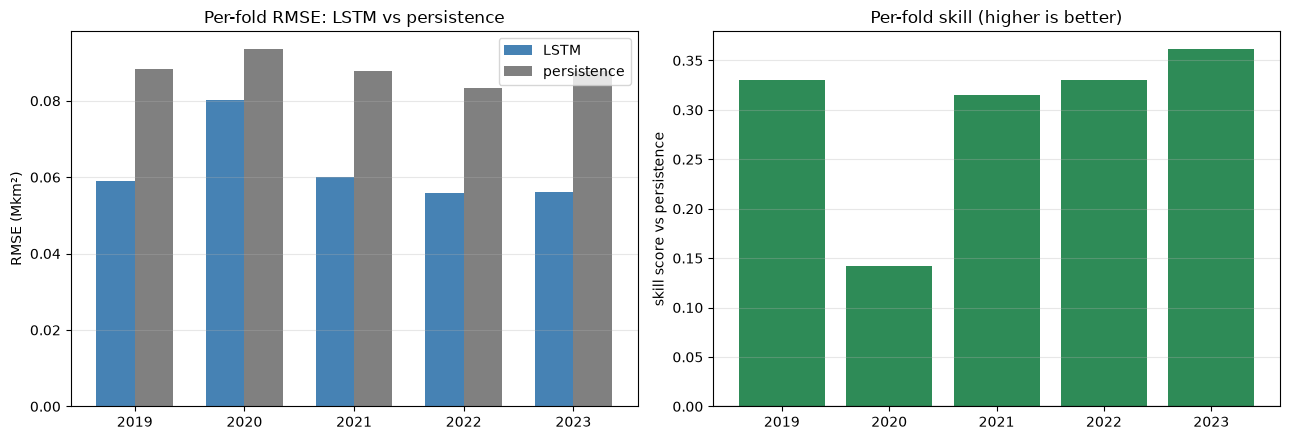

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

width = 0.35
x = np.arange(len(results_df))
axes[0].bar(x - width/2, results_df["rmse_lstm"], width, label="LSTM", color="steelblue")
axes[0].bar(x + width/2, results_df["rmse_persistence"], width, label="persistence", color="gray")
axes[0].set_xticks(x); axes[0].set_xticklabels(results_df["test_year"])
axes[0].set_ylabel("RMSE (Mkm²)"); axes[0].set_title("Per-fold RMSE: LSTM vs persistence")
axes[0].legend(); axes[0].grid(alpha=0.3, axis="y")

axes[1].bar(x, results_df["skill_vs_persistence"], color="seagreen")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(results_df["test_year"])
axes[1].set_ylabel("skill score vs persistence"); axes[1].set_title("Per-fold skill (higher is better)")
axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
import os; os.makedirs("../results/figures", exist_ok=True)
plt.savefig("../results/figures/backtest_expanding_window.png", dpi=120, bbox_inches="tight")
plt.show()

In [7]:
log_model_results(
    model_name="LSTM_Backtest_Univariate_Mean",
    metrics={
        "rmse": results_df["rmse_lstm"].mean(),
        "mae": float("nan"),
        "mape": float("nan"),
        "skill_score_persistence": results_df["skill_vs_persistence"].mean(),
        "skill_score_climatology": results_df["skill_vs_climatology"].mean(),
    },
    scale="daily",
    metadata={
        "architecture": f"{config.num_layers}-layer LSTM, {config.hidden_size} hidden, dropout={config.dropout}",
        "input_features": "extent_mkm2 (univariate)",
        "note": "mean over 5 expanding-window folds (test years 2019-2023); "
                f"rmse_std={results_df['rmse_lstm'].std():.4f}, "
                f"beats_persistence_in={int(beats_persistence.sum())}/5 folds",
        "seed": config.seed,
    },
    output_file="../results/model_comparison.csv",
)

✓ Logged results for LSTM_Backtest_Univariate_Mean to ../results/model_comparison.csv


## Findings

**5/5 folds: the univariate LSTM beats persistence**, so `04_basic_lstm`'s single-split result
wasn't a lucky draw:

| test year | RMSE (LSTM) | RMSE (persistence) | skill vs persistence |
|---|---|---|---|
| 2019 | 0.0591 | 0.0882 | +0.330 |
| 2020 | 0.0802 | 0.0935 | +0.142 |
| 2021 | 0.0602 | 0.0878 | +0.315 |
| 2022 | 0.0559 | 0.0834 | +0.330 |
| 2023 | 0.0561 | 0.0878 | +0.361 |

- **RMSE (LSTM): 0.0623 ± 0.0102 Mkm²** vs **RMSE (persistence): 0.0882 ± 0.0036 Mkm²** — lower
  than `04`'s single fixed-split RMSE (0.0726), since most folds here train on more years of
  history than the fixed 1989-2014 split used there.
- **Skill vs persistence: +0.296 ± 0.088**, noticeably higher than `04`'s single-split +0.168, and
  positive in every one of the 5 folds. This is the result we actually wanted: the LSTM's edge
  over persistence is not an artifact of the 2020-2023 test window choice.
- **2020 is the weakest fold** (skill +0.142, well below the other four's ~+0.32-0.36) — plausibly
  the training/val windows ending right at the COVID-adjacent 2018-2019 period, or just a harder
  year for the ice extent series itself; worth a look if this pattern recurs once the multivariate
  variants are backtested too.
- Fold-to-fold RMSE variance (std 0.0102, ~16% of the mean) is real but the LSTM never comes close
  to losing to persistence, so the finding is robust, not fragile.